# Multi-Asset Portfolio VaR/ES Dashboard

15-ticker US equity portfolio, $10mm notional. Daily and 5-day 99% VaR/ES via
Historical Simulation and Monte Carlo (normal). Stress-tested against 2008 GFC,
March 2020, and 2022 rate hikes.

Repo: github.com/tianxinghu/var-dashboard

In [ ]:
import sys
from pathlib import Path

# notebook lives in notebooks/, src/ is sibling
sys.path.insert(0, str(Path.cwd().parent / "src"))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from portfolio    import HOLDINGS, NOTIONAL
from returns      import fetch_prices, daily_returns, portfolio_returns
from var          import historical_var, historical_es, rolling_returns
from monte_carlo  import mc_var, mc_es, mc_returns_normal
from stress       import WINDOWS, stress_stats

plt.rcParams["figure.figsize"] = (10, 5)
plt.rcParams["figure.dpi"]     = 100

# colors for hist vs MC comparison (used across the notebook)
C_HIST = "navy"
C_MC   = "firebrick"

## Portfolio

15 large-cap US equities, $10mm notional, weights roughly mirror S&P 500 sector
exposure. All tickers have pre-2007 history so the GFC window is in-sample.

In [3]:
# build holdings DataFrame for display
holdings_df = pd.DataFrame(
    [(t, sec, w, NOTIONAL * w) for t, (sec, w) in HOLDINGS.items()],
    columns=["ticker", "sector", "weight", "dollar_position"],
).sort_values("weight", ascending=False).reset_index(drop=True)

holdings_df

,ticker,sector,weight,dollar_position
0,AAPL,Information Technology,0.10,1000000.0
1,MSFT,Information Technology,0.10,1000000.0
2,JPM,Financials,0.08,800000.0
3,JNJ,Health Care,0.08,800000.0
4,AMZN,Consumer Discretionary,0.08,800000.0
5,UNH,Health Care,0.07,700000.0
6,CAT,Industrials,0.07,700000.0
7,XOM,Energy,0.07,700000.0
8,BAC,Financials,0.06,600000.0
9,GS,Financials,0.06,600000.0


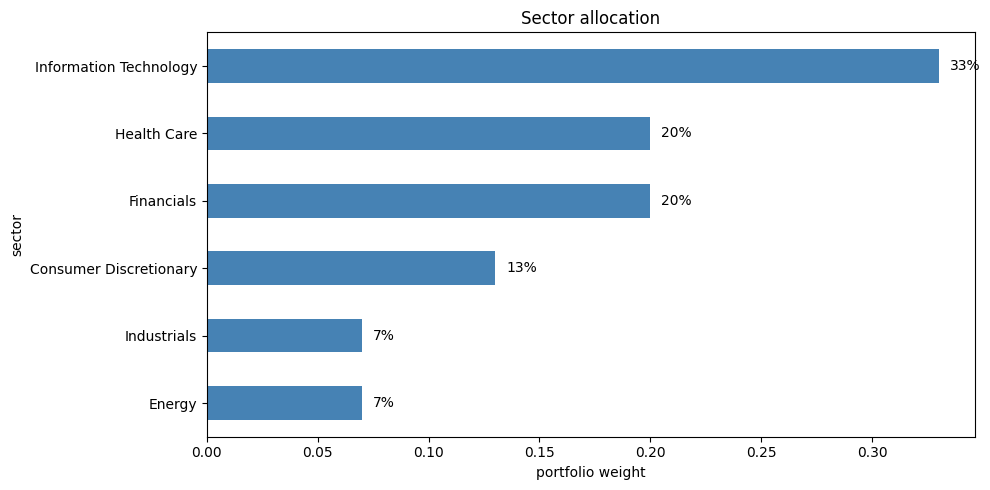

In [4]:
# sector weights
sector_w = (
    holdings_df.groupby("sector")["weight"]
    .sum()
    .sort_values(ascending=True)   # ascending so largest sits on top in barh
)

fig, ax = plt.subplots()
sector_w.plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("portfolio weight")
ax.set_title("Sector allocation")
for i, v in enumerate(sector_w):
    ax.text(v + 0.005, i, f"{v:.0%}", va="center")
plt.tight_layout()
plt.show()

## Returns

2007 to today via Yahoo Finance. Three things worth looking at: the cumulative return
path (GFC / March 2020 / 2022 selloff all visible), annualized stats (vol, skew,
kurtosis), and distribution shape vs normal. The last one previews why VaR and ES
will diverge in the sections below.

In [12]:
prices = fetch_prices()
asset_returns = daily_returns(prices)
port_returns  = portfolio_returns(asset_returns)

# sanity check
n     = len(port_returns)
start = port_returns.index[0].date()
end   = port_returns.index[-1].date()
print(f"{n:,} trading days, {start} to {end}")
print(f"ann mean: {port_returns.mean() * 252:.2%}")
print(f"ann vol:  {port_returns.std() * np.sqrt(252):.2%}")

4,873 trading days, 2007-01-04 to 2026-05-18
ann mean: 20.11%
ann vol:  22.11%


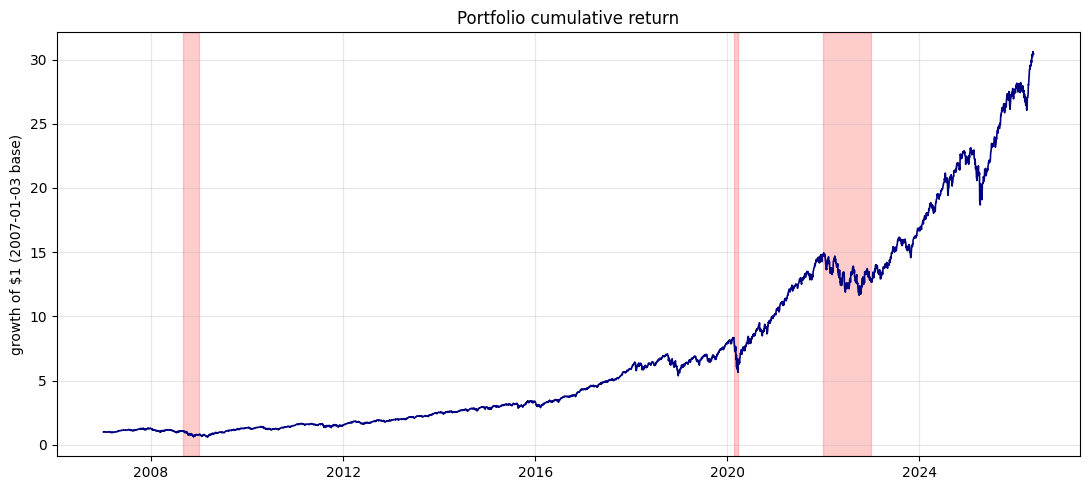

In [7]:
# cumulative returns with the three stress windows shaded
cum_returns = (1 + port_returns).cumprod()

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(cum_returns.index, cum_returns.values, color="navy", linewidth=1.2)

# shade the stress windows we'll dig into in section 6
for start, end in WINDOWS.values():
    ax.axvspan(start, end, alpha=0.2, color="red")

ax.set_ylabel("growth of $1 (2007-01-03 base)")
ax.set_title("Portfolio cumulative return")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [11]:
from scipy import stats

print(f"n days:       {len(port_returns):>7,}")
print(f"ann return:   {port_returns.mean() * 252:>7.2%}")
print(f"ann vol:      {port_returns.std() * np.sqrt(252):>7.2%}")
print(f"skew:         {stats.skew(port_returns):>7.2f}")
print(f"excess kurt:  {stats.kurtosis(port_returns):>7.2f}   (normal = 0; >0 means fat tails)")
print(f"worst day:    {port_returns.min():>7.2%}   on {port_returns.idxmin().date()}")
print(f"best day:     {port_returns.max():>7.2%}   on {port_returns.idxmax().date()}")

n days:         4,873
ann return:    20.11%
ann vol:       22.11%
skew:            0.14
excess kurt:    12.70   (normal = 0; >0 means fat tails)
worst day:    -12.02%   on 2020-03-16
best day:      14.88%   on 2008-10-13


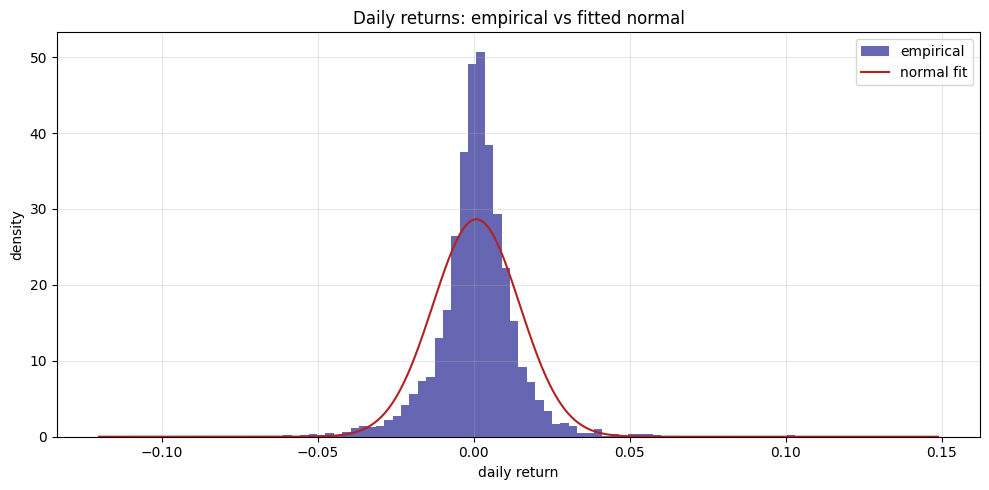

In [13]:
# daily return distribution vs fitted normal
mu, sigma = port_returns.mean(), port_returns.std()

fig, ax = plt.subplots()
ax.hist(port_returns, bins=100, density=True, alpha=0.6, color="navy", label="empirical")

# normal pdf with sample mu, sigma
x = np.linspace(port_returns.min(), port_returns.max(), 500)
ax.plot(x, stats.norm.pdf(x, mu, sigma), color="firebrick", linewidth=1.5, label="normal fit")

ax.set_xlabel("daily return")
ax.set_ylabel("density")
ax.set_title("Daily returns: empirical vs fitted normal")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Daily VaR/ES (1-day, 99%)

Two methods on the same return series. Historical Simulation: take the 1% empirical
quantile of the 4,873-day return distribution. Monte Carlo Normal: fit μ, σ to the
sample, draw 10,000 IID daily returns from N(μ, σ²), take the 1% quantile of those.

The two should agree if returns are normal. They don't, because returns aren't
normal (excess kurt 12.7, just measured). The gap is the FRTB argument in one line.

In [15]:
from IPython.display import display

hist_var_1d = historical_var(port_returns)
hist_es_1d  = historical_es(port_returns)
mc_var_1d   = mc_var(port_returns)
mc_es_1d    = mc_es(port_returns)

var_1d = pd.DataFrame({
    "Historical":  [hist_var_1d, hist_es_1d],
    "Monte Carlo": [mc_var_1d,   mc_es_1d],
    "Hist / MC":   [hist_var_1d / mc_var_1d, hist_es_1d / mc_es_1d],
}, index=["VaR (99%)", "ES (99%)"])

display(var_1d.style.format({
    "Historical":  "{:.2%}",
    "Monte Carlo": "{:.2%}",
    "Hist / MC":   "{:.2f}x",
}))

# in dollar terms
print(f"\non ${NOTIONAL:,.0f} notional, 1-day 99% ES:")
print(f"  Historical:   ${hist_es_1d * NOTIONAL:>11,.0f}")
print(f"  Monte Carlo:  ${mc_es_1d  * NOTIONAL:>11,.0f}")
print(f"  MC underprices the tail by ${(hist_es_1d - mc_es_1d) * NOTIONAL:,.0f} "
      f"({(hist_es_1d - mc_es_1d)/hist_es_1d:+.0%})")

,Historical,Monte Carlo,Hist / MC
VaR (99%),3.89%,3.23%,1.21x
ES (99%),5.70%,3.71%,1.54x



on $10,000,000 notional, 1-day 99% ES:
  Historical:   $    570,443
  Monte Carlo:  $    371,490
  MC underprices the tail by $198,953 (+35%)


## 5-day VaR/ES (99%)

Same idea, longer horizon. Compute rolling 5-day cumulative returns and take the
1% quantile. For Historical Simulation this uses overlapping 5-day windows from
the actual return series. For Monte Carlo I sum 5 IID daily draws from N(μ, σ²).

Key choice: rolling 5-day returns rather than √T scaling of 1-day VaR. The
scaling shortcut assumes IID returns, which they're not. There's serial dependence
(vol clustering), and rolling windows preserve that structure.

In [16]:
# rolling 5-day cumulative returns
port_returns_5d = rolling_returns(port_returns, 5).dropna()

hist_var_5d = historical_var(port_returns_5d)
hist_es_5d  = historical_es(port_returns_5d)
mc_var_5d   = mc_var(port_returns, horizon=5)
mc_es_5d    = mc_es(port_returns, horizon=5)

var_5d = pd.DataFrame({
    "Historical":  [hist_var_5d, hist_es_5d],
    "Monte Carlo": [mc_var_5d,   mc_es_5d],
    "Hist / MC":   [hist_var_5d / mc_var_5d, hist_es_5d / mc_es_5d],
}, index=["VaR (99%)", "ES (99%)"])

display(var_5d.style.format({
    "Historical":  "{:.2%}",
    "Monte Carlo": "{:.2%}",
    "Hist / MC":   "{:.2f}x",
}))

# in dollar terms
print(f"\non ${NOTIONAL:,.0f} notional, 5-day 99% ES:")
print(f"  Historical:   ${hist_es_5d * NOTIONAL:>11,.0f}")
print(f"  Monte Carlo:  ${mc_es_5d  * NOTIONAL:>11,.0f}")
print(f"  MC underprices the tail by ${(hist_es_5d - mc_es_5d) * NOTIONAL:,.0f} "
      f"({(hist_es_5d - mc_es_5d)/hist_es_5d:+.0%})")

,Historical,Monte Carlo,Hist / MC
VaR (99%),8.06%,6.82%,1.18x
ES (99%),11.33%,7.70%,1.47x



on $10,000,000 notional, 5-day 99% ES:
  Historical:   $  1,133,158
  Monte Carlo:  $    769,638
  MC underprices the tail by $363,520 (+32%)


## Stress tests

Three historical crisis windows, each compared against the model 5-day 99% VaR.
Worst observed 5-day losses run 2-3× the model threshold. Models calibrate to
calm periods; crises live outside the in-sample distribution. This is the
empirical basis for the FRTB shift to stressed ES.

In [17]:
# run stress_stats on each crisis window
rows = []
for name, (start, end) in WINDOWS.items():
    s = stress_stats(port_returns, start, end)
    rows.append({
        "window":   name,
        "worst 1d": s["worst_1d"],
        "worst 5d": s["worst_5d"],
        "drawdown": s["drawdown"],
    })

stress_df = pd.DataFrame(rows).set_index("window")

# multiplier vs model 5d VaR
stress_df["× 5d VaR"] = stress_df["worst 5d"].abs() / hist_var_5d

display(stress_df.style.format({
    "worst 1d":  "{:.2%}",
    "worst 5d":  "{:.2%}",
    "drawdown":  "{:.2%}",
    "× 5d VaR":  "{:.2f}x",
}))

print(f"\nreference: model 5-day 99% VaR (historical) = {hist_var_5d:.2%}")
print(f"           model 5-day 99% ES  (historical) = {hist_es_5d:.2%}")

,worst 1d,worst 5d,drawdown,× 5d VaR
window,,,,
2008 GFC,-11.21%,-20.18%,-42.37%,2.50x
March 2020 COVID,-12.02%,-18.14%,-32.42%,2.25x
2022 rate hikes,-4.64%,-10.34%,-22.09%,1.28x



reference: model 5-day 99% VaR (historical) = 8.06%
           model 5-day 99% ES  (historical) = 11.33%


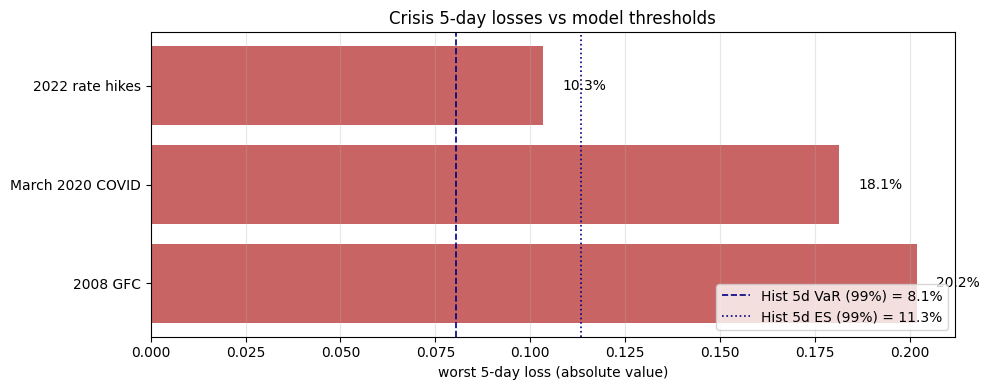

In [18]:
# crisis 5d losses vs model thresholds
window_names  = list(WINDOWS.keys())
worst_5d_vals = [abs(stress_df.loc[w, "worst 5d"]) for w in window_names]

fig, ax = plt.subplots(figsize=(10, 4))
y_pos = np.arange(len(window_names))
ax.barh(y_pos, worst_5d_vals, color="firebrick", alpha=0.7)
ax.set_yticks(y_pos)
ax.set_yticklabels(window_names)
ax.set_xlabel("worst 5-day loss (absolute value)")
ax.set_title("Crisis 5-day losses vs model thresholds")

# vertical reference lines at model VaR and ES
ax.axvline(hist_var_5d, color="navy", linestyle="--", linewidth=1.2,
           label=f"Hist 5d VaR (99%) = {hist_var_5d:.1%}")
ax.axvline(hist_es_5d,  color="navy", linestyle=":",  linewidth=1.2,
           label=f"Hist 5d ES (99%) = {hist_es_5d:.1%}")

# label each bar
for i, v in enumerate(worst_5d_vals):
    ax.text(v + 0.005, i, f"{v:.1%}", va="center")

ax.legend(loc="lower right")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()

## Conclusion

Normal-fit Monte Carlo underprices the empirical tail. 1-day Hist ES sits 1.54×
higher than MC ES; 5-day at 1.47× (smaller because CLT smooths longer-horizon
tails). Both gaps are quantitative evidence behind the FRTB 2016 shift from VaR
to stressed ES.

Crisis 5-day losses run 2-3× the model 5-day 99% VaR (2008 GFC: 2.50×, March
2020: 2.25×, 2022 rate hikes: 1.28×). The model is reliable in calm regimes and
broken in crisis ones. Stressed ES (ES computed on a stressed historical window)
is the FRTB response, thou